# Sprint 5 — Business Value

## Definición de supuestos de impacto económico

Para evaluar el impacto económico del modelo no basta con revisar métricas técnicas como `recall`, `precision` o `F2`. Es necesario traducir la matriz de confusión a términos de negocio.

En este problema, el modelo predice si un auto será un `Bad Buy` (`IsBadBuy = 1`). Por lo tanto, cada tipo de error tiene una consecuencia económica distinta:

| Caso | Interpretación | Impacto de negocio |
|---|---|---|
| **TP** | El modelo detecta correctamente un Bad Buy | Se evita comprar un auto riesgoso |
| **FP** | El modelo marca como Bad Buy un auto que era bueno | Se pierde una oportunidad comercial |
| **FN** | El modelo deja pasar un Bad Buy | Se compra un auto riesgoso |
| **TN** | El modelo acepta correctamente un auto bueno | Se mantiene una oportunidad comercial normal |

El objetivo principal del modelo es reducir el riesgo de comprar autos malos.

A partir del análisis de variables económicas del dataset, se observa que:

- Los autos buenos tienen un margen neto esperado positivo.
- Los `Bad Buys` tienden a mostrar menor margen esperado.
- Los `Bad Buys` tienen mayores costos asociados, especialmente por garantía y sobrepago relativo.
- Rechazar un auto bueno tiene un costo, pero dejar pasar un `Bad Buy` debería representar una pérdida mayor para el negocio.

Una estimación razonable del costo de dejar pasar un `Bad Buy` considera:

```text
WarrantyCost mediano de Bad Buy
+ margen neto esperado perdido de un auto bueno
+ sobrepago adicional estimado
≈ 2,500

BusinessValue(t) = TP(t) * 2500 + FP(t) * (-900) + FN(t) * 0 + TN(t) * 0

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
)

from src.config import *
from src.preprocessing import split_X_y
from src.evaluation import get_scores, gain_curve

pd.set_option("display.max_columns", 120)
print("Proyecto:", PROJECT_ROOT)

Proyecto: /Users/alexandralozano/dp261-g1


In [2]:
# Cargar modelo final y test holdout.

MODEL_PATH = MODELS_DIR / "final_model.pkl"
TEST_PATH = PROCESSED_DIR / "test_final.csv"
OPERATING_THRESHOLD = 0.50

model = joblib.load(MODEL_PATH)
test_final = pd.read_csv(TEST_PATH)

X_test, y_test = split_X_y(test_final)
y_score = get_scores(model, X_test)

threshold_grid = np.round(np.arange(0.01, 0.96, 0.01), 2)

print("Modelo:", MODEL_PATH)
print("Test:", TEST_PATH)
print("Registros test:", len(y_test))
print("Bad Buy rate real:", round(y_test.mean(), 4))

Modelo: /Users/alexandralozano/dp261-g1/models/final_model.pkl
Test: /Users/alexandralozano/dp261-g1/data/processed/test_final.csv
Registros test: 14597
Bad Buy rate real: 0.123


In [3]:
# Evaluar thresholds con métricas técnicas y valor económico.
# Cambiar estos supuestos en src.config si negocio define costos/beneficios distintos.

rows = []

for threshold in threshold_grid:
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    tp_value = tp * BENEFIT_TP
    fp_value = fp * COST_FP
    fn_value = fn * COST_FN
    tn_value = tn * BENEFIT_TN
    business_value = tp_value + fp_value + fn_value + tn_value

    rows.append({
        "threshold": threshold,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "tn_value": tn_value,
        "fp_value": fp_value,
        "fn_value": fn_value,
        "tp_value": tp_value,
        "business_value": business_value,
        "avg_value_per_vehicle": business_value / len(y_test),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f05": fbeta_score(y_test, y_pred, beta=0.5, zero_division=0),
        "positive_rate": y_pred.mean(),
        "fn_rate": fn / max(fn + tp, 1),
        "fp_rate": fp / max(fp + tn, 1),
        "predicted_bad_buy": int(tp + fp),
        "predicted_good_buy": int(tn + fn),
        "roc_auc": roc_auc_score(y_test, y_score),
        "average_precision": average_precision_score(y_test, y_score),
    })

threshold_business_value = (
    pd.DataFrame(rows)
    .sort_values(["business_value", "recall", "f2", "precision"], ascending=[False, False, False, False])
    .reset_index(drop=True)
)

threshold_business_value_path = REPORTS_DIR / "threshold_business_value.csv"
threshold_business_value.to_csv(threshold_business_value_path, index=False)

display(threshold_business_value[[
    "threshold", "business_value", "avg_value_per_vehicle",
    "recall", "f2", "precision", "positive_rate",
    "tp", "fp", "fn", "tn"
]].head(10))

print("Guardado:", threshold_business_value_path)

,threshold,business_value,avg_value_per_vehicle,recall,f2,precision,positive_rate,tp,fp,fn,tn
0,0.70,1079600,73.960403,0.367131,0.389020,0.510853,0.088374,659,631,1136,12171
1,0.68,1069100,73.241077,0.388858,0.404450,0.481712,0.099267,698,751,1097,12051
2,0.71,1066300,73.049257,0.356546,0.380364,0.519059,0.084469,640,593,1155,12209
3,0.75,1065300,72.980749,0.319220,0.351060,0.584098,0.067206,573,408,1222,12394
4,0.69,1065100,72.967048,0.374930,0.394074,0.495217,0.093101,673,686,1122,12116
5,0.67,1051300,72.021648,0.398329,0.410306,0.466406,0.105022,715,818,1080,11984
6,0.74,1049600,71.905186,0.325348,0.355231,0.561538,0.071248,584,456,1211,12346
7,0.78,1048600,71.836679,0.298050,0.332877,0.625000,0.058642,535,321,1260,12481
8,0.76,1046000,71.658560,0.310306,0.342896,0.591295,0.064534,557,385,1238,12417
9,0.73,1044600,71.562650,0.334262,0.362056,0.542495,0.075769,600,506,1195,12296


Guardado: /Users/alexandralozano/dp261-g1/reports/threshold_business_value.csv


In [4]:
# Comparar threshold operativo 0.50 vs threshold óptimo por valor económico.

operational = (
    threshold_business_value
    .iloc[(threshold_business_value["threshold"] - OPERATING_THRESHOLD).abs().argsort()[:1]]
    .copy()
)
operational["scenario"] = "operational_0_50"

business_optimal = threshold_business_value.head(1).copy()
business_optimal["scenario"] = "business_optimal"

threshold_business_comparison = (
    pd.concat([operational, business_optimal], ignore_index=True)
    .drop_duplicates(subset=["scenario"])
)

scenario_cols = [
    "scenario", "threshold", "business_value", "avg_value_per_vehicle",
    "recall", "f2", "precision", "positive_rate",
    "tp", "fp", "fn", "tn", "tp_value", "fp_value", "fn_value", "tn_value"
]

threshold_business_comparison_path = REPORTS_DIR / "threshold_business_value_comparison.csv"
threshold_business_comparison.to_csv(threshold_business_comparison_path, index=False)

display(threshold_business_comparison[scenario_cols])
print("Guardado:", threshold_business_comparison_path)

,scenario,threshold,business_value,avg_value_per_vehicle,recall,f2,precision,positive_rate,tp,fp,fn,tn,tp_value,fp_value,fn_value,tn_value
0,operational_0_50,0.5,26500,1.815442,0.615599,0.487859,0.266586,0.283962,1105,3040,690,9762,2762500,-2736000,0,0
1,business_optimal,0.7,1079600,73.960403,0.367131,0.389020,0.510853,0.088374,659,631,1136,12171,1647500,-567900,0,0


Guardado: /Users/alexandralozano/dp261-g1/reports/threshold_business_value_comparison.csv


In [5]:
# Matriz de confusión traducida a impacto económico por escenario.

impact_rows = []

for _, row in threshold_business_comparison.iterrows():
    impact_rows.extend([
        {
            "scenario": row["scenario"],
            "threshold": row["threshold"],
            "confusion_cell": "TP_bad_buy_detected",
            "count": int(row["tp"]),
            "unit_value": BENEFIT_TP,
            "total_value": row["tp_value"],
            "business_meaning": "Bad Buy detectado; se evita comprar una unidad riesgosa",
        },
        {
            "scenario": row["scenario"],
            "threshold": row["threshold"],
            "confusion_cell": "FP_good_buy_rejected",
            "count": int(row["fp"]),
            "unit_value": COST_FP,
            "total_value": row["fp_value"],
            "business_meaning": "Auto bueno marcado como malo; se pierde oportunidad comercial",
        },
        {
            "scenario": row["scenario"],
            "threshold": row["threshold"],
            "confusion_cell": "FN_bad_buy_missed",
            "count": int(row["fn"]),
            "unit_value": COST_FN,
            "total_value": row["fn_value"],
            "business_meaning": "Bad Buy no detectado; se acepta una unidad riesgosa",
        },
        {
            "scenario": row["scenario"],
            "threshold": row["threshold"],
            "confusion_cell": "TN_good_buy_accepted",
            "count": int(row["tn"]),
            "unit_value": BENEFIT_TN,
            "total_value": row["tn_value"],
            "business_meaning": "Auto bueno aceptado; flujo normal de compra",
        },
    ])

business_confusion_impact = pd.DataFrame(impact_rows)
business_confusion_impact_path = REPORTS_DIR / "business_confusion_matrix_impact.csv"
business_confusion_impact.to_csv(business_confusion_impact_path, index=False)

display(business_confusion_impact)
print("Guardado:", business_confusion_impact_path)

,scenario,threshold,confusion_cell,count,unit_value,total_value,business_meaning
0,operational_0_50,0.5,TP_bad_buy_detected,1105,2500,2762500,Bad Buy detectado; se evita comprar una unidad...
1,operational_0_50,0.5,FP_good_buy_rejected,3040,-900,-2736000,Auto bueno marcado como malo; se pierde oportu...
2,operational_0_50,0.5,FN_bad_buy_missed,690,0,0,Bad Buy no detectado; se acepta una unidad rie...
3,operational_0_50,0.5,TN_good_buy_accepted,9762,0,0,Auto bueno aceptado; flujo normal de compra
4,business_optimal,0.7,TP_bad_buy_detected,659,2500,1647500,Bad Buy detectado; se evita comprar una unidad...
5,business_optimal,0.7,FP_good_buy_rejected,631,-900,-567900,Auto bueno marcado como malo; se pierde oportu...
6,business_optimal,0.7,FN_bad_buy_missed,1136,0,0,Bad Buy no detectado; se acepta una unidad rie...
7,business_optimal,0.7,TN_good_buy_accepted,12171,0,0,Auto bueno aceptado; flujo normal de compra


Guardado: /Users/alexandralozano/dp261-g1/reports/business_confusion_matrix_impact.csv


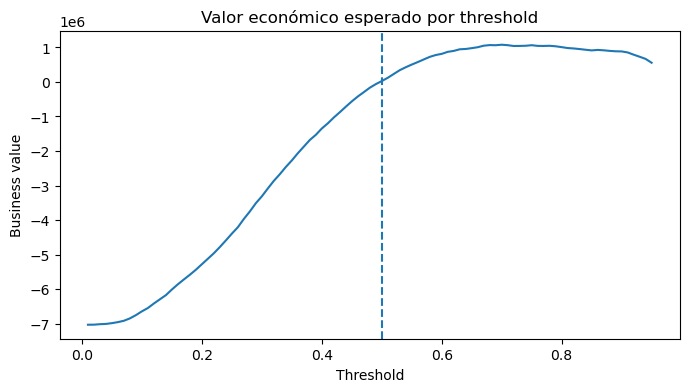

In [6]:
# Visualizar valor económico por threshold.

threshold_plot = threshold_business_value.sort_values("threshold")
ax = threshold_plot.plot(x="threshold", y="business_value", figsize=(8, 4), legend=False)
ax.axvline(OPERATING_THRESHOLD, linestyle="--")
ax.set_title("Valor económico esperado por threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Business value")
plt.show()

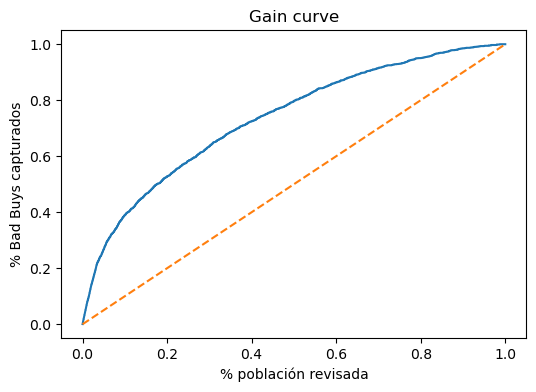

Guardado: /Users/alexandralozano/dp261-g1/reports/gain_curve.csv


In [7]:
# Gain curve para evaluar concentración de Bad Buys por score.

gains = gain_curve(y_test, y_score)
gain_curve_path = REPORTS_DIR / "gain_curve.csv"
gains.to_csv(gain_curve_path, index=False)

ax = gains.plot(x="pct_population", y="pct_positives_captured", figsize=(6, 4), legend=False)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Gain curve")
ax.set_xlabel("% población revisada")
ax.set_ylabel("% Bad Buys capturados")
plt.show()

print("Guardado:", gain_curve_path)

In [8]:
# Lectura rápida para decisión.

op = threshold_business_comparison.query("scenario == 'operational_0_50'").iloc[0]
best = threshold_business_comparison.query("scenario == 'business_optimal'").iloc[0]
delta = best["business_value"] - op["business_value"]

print(f"Threshold operativo: {op['threshold']:.2f} | Valor: {op['business_value']:,.0f} | Recall: {op['recall']:.3f} | Precision: {op['precision']:.3f}")
print(f"Threshold óptimo económico: {best['threshold']:.2f} | Valor: {best['business_value']:,.0f} | Recall: {best['recall']:.3f} | Precision: {best['precision']:.3f}")
print(f"Diferencia de valor vs 0.50: {delta:,.0f}")

if best["threshold"] != op["threshold"]:
    print("Recomendación: evaluar el threshold óptimo económico con negocio antes de mantener 0.50.")
else:
    print("Recomendación: mantener 0.50; también maximiza valor bajo estos supuestos.")

Threshold operativo: 0.50 | Valor: 26,500 | Recall: 0.616 | Precision: 0.267
Threshold óptimo económico: 0.70 | Valor: 1,079,600 | Recall: 0.367 | Precision: 0.511
Diferencia de valor vs 0.50: 1,053,100
Recomendación: evaluar el threshold óptimo económico con negocio antes de mantener 0.50.


Inicialmente se evaluó el modelo con threshold 0.50 por ser el umbral estándar y porque ofrecía mayor recall. Sin embargo, al traducir la matriz de confusión a impacto económico, se observó que el threshold 0.50 rechazaba demasiados autos buenos, reduciendo casi por completo el valor incremental del modelo. Bajo los supuestos económicos definidos, el threshold 0.70 maximiza el valor esperado, ya que mantiene una detección relevante de Bad Buys y reduce significativamente los falsos positivos.